# Bakery sales demo: quantity modelling with LMM and revenue estimation

This notebook does two connected tasks:

1. Model bakery item demand (`quantity`) using a Linear Mixed Effects Model (LMM)
2. Convert predicted demand into pseudo revenue using owner-adjustable prices

This is useful because:

- quantity is learned from data
- price is controlled by bakery owners
- revenue can be estimated under different pricing assumptions

In [23]:
# Core data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Mixed effects modelling
import statsmodels.formula.api as smf

# Simple model evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Optional: display wider tables more clearly in notebooks
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the bakery data

We first load the CSV file and keep the raw version unchanged.
This makes debugging easier later.

In [ ]:
# Load the raw bakery sales file
# Change the path here if your CSV is stored in another folder, for example:
# df_raw = pd.read_csv("data/bakery_sales_revised.csv")

df_raw = pd.read_csv("demo/bakery_kaggle/bakery_sales_revised.csv")

# Show the first few rows
df_raw.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,10/30/2016 9:58,morning,weekend
1,2,Scandinavian,10/30/2016 10:05,morning,weekend
2,2,Scandinavian,10/30/2016 10:05,morning,weekend
3,3,Hot chocolate,10/30/2016 10:07,morning,weekend
4,3,Jam,10/30/2016 10:07,morning,weekend


In [25]:
# Print key structural information about the raw data
print("Shape of raw data:", df_raw.shape)
print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
print(df_raw.dtypes)

print("\nMissing values per column:")
print(df_raw.isna().sum())

Shape of raw data: (20507, 5)

Column names:
['Transaction', 'Item', 'date_time', 'period_day', 'weekday_weekend']

Data types:
Transaction        int64
Item                 str
date_time            str
period_day           str
weekday_weekend      str
dtype: object

Missing values per column:
Transaction        0
Item               0
date_time          0
period_day         0
weekday_weekend    0
dtype: int64


## 2. Parse datetime and create useful time features

The raw file includes `date_time`, which we convert into a proper datetime field.
We also derive a date, hour, month, and day name for later analysis.

In [26]:
# Work on a copy so the raw data stays untouched
df = df_raw.copy()

# Convert date_time into pandas datetime
# errors="coerce" means invalid date strings become NaT instead of crashing
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")

# Derive extra time-related fields that may be useful later
df["date"] = df["date_time"].dt.date          # calendar date only
df["hour"] = df["date_time"].dt.hour          # hour of day
df["month"] = df["date_time"].dt.month        # month number
df["day_name"] = df["date_time"].dt.day_name()  # Monday, Tuesday, etc.

# Show a preview of the new columns
df[["date_time", "date", "hour", "month", "day_name"]].head()

,date_time,date,hour,month,day_name
0,2016-10-30 09:58:00,2016-10-30,9,10,Sunday
1,2016-10-30 10:05:00,2016-10-30,10,10,Sunday
2,2016-10-30 10:05:00,2016-10-30,10,10,Sunday
3,2016-10-30 10:07:00,2016-10-30,10,10,Sunday
4,2016-10-30 10:07:00,2016-10-30,10,10,Sunday


In [27]:
# Check whether datetime parsing worked properly
print("Number of missing/invalid date_time values:", df["date_time"].isna().sum())

# Show a few rows where parsing failed, if any
df[df["date_time"].isna()].head()

Number of missing/invalid date_time values: 0


,Transaction,Item,date_time,period_day,weekday_weekend,date,hour,month,day_name


## 3. Aggregate raw transactions into item-level quantity

The raw dataset is one row per sold item.
To model quantity, we aggregate rows by:

- date
- item
- period of day
- weekday/weekend

The resulting `quantity` is the number of units sold for that item under that context.

In [28]:
# Aggregate transactions into quantity sold
# Each row in qty_df will represent one item-context combination
qty_df = (
    df.groupby(["date", "Item", "period_day", "weekday_weekend"])
      .size()
      .reset_index(name="quantity")
)

# Show the first few aggregated rows
qty_df.head()

,date,Item,period_day,weekday_weekend,quantity
0,2016-10-30,Basket,morning,weekend,2
1,2016-10-30,Bread,afternoon,weekend,9
2,2016-10-30,Bread,morning,weekend,20
3,2016-10-30,Cake,afternoon,weekend,1
4,2016-10-30,Chicken sand,afternoon,weekend,1


In [29]:
# Basic checks on the aggregated quantity table
print("Shape of quantity table:", qty_df.shape)
print("Number of unique items:", qty_df["Item"].nunique())

print("\nQuantity summary:")
print(qty_df["quantity"].describe())

print("\nTop rows by quantity:")
display(qty_df.sort_values("quantity", ascending=False).head(10))

Shape of quantity table: (5627, 5)
Number of unique items: 94

Quantity summary:
count    5627.000000
mean        3.644393
std         4.603694
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        39.000000
Name: quantity, dtype: float64

Top rows by quantity:


,date,Item,period_day,weekday_weekend,quantity
3172,2017-02-04,Coffee,afternoon,weekend,39
251,2016-11-05,Coffee,morning,weekend,39
4045,2017-02-26,Coffee,afternoon,weekend,37
45,2016-10-31,Coffee,morning,weekday,36
793,2016-11-19,Coffee,morning,weekend,34
5013,2017-03-25,Coffee,afternoon,weekend,32
250,2016-11-05,Coffee,afternoon,weekend,32
2891,2017-01-28,Coffee,morning,weekend,32
3229,2017-02-05,Coffee,afternoon,weekend,32
2191,2017-01-07,Coffee,afternoon,weekend,32


## 4. Create pseudo prices

The original dataset has no real price information.

So we create a pseudo price layer:
- some items get manually assigned example prices
- all other items receive a default fallback price

This price layer is deliberately separate from the statistical model.
That means bakery owners can later adjust prices without retraining the model.

In [30]:
# Define base pseudo prices for common bakery items
# These are example values only, and can later be replaced by real owner inputs
base_price_map = {
    "Coffee": 2.8,
    "Bread": 3.5,
    "Tea": 2.5,
    "Cake": 4.8,
    "Pastry": 3.8,
    "Sandwich": 5.5,
    "Medialuna": 2.7,
    "Hot chocolate": 3.2,
    "Cookies": 2.4,
    "Brownie": 3.0,
    "Farm House": 4.5,
    "Muffin": 2.9,
    "Alfajores": 2.6,
    "Juice": 3.0,
    "Soup": 4.9,
    "Scone": 2.8,
    "Toast": 3.2,
    "Scandinavian": 3.8,
    "Truffles": 3.4,
    "Coke": 2.2
}

# Default fallback price for items not in the manual price map
default_price = 3.5

# Map prices to each item
qty_df["base_price"] = qty_df["Item"].map(base_price_map).fillna(default_price)

# Preview item-price assignments
qty_df[["Item", "base_price"]].drop_duplicates().sort_values("Item").head(20)

,Item,base_price
409,Adjustment,3.5
2163,Afternoon with the baker,3.5
76,Alfajores,2.6
4472,Argentina Night,3.5
370,Art Tray,3.5
571,Bacon,3.5
2785,Baguette,3.5
1017,Bakewell,3.5
1594,Bare Popcorn,3.5
0,Basket,3.5


In [31]:
# Identify which items are still using the default fallback price
missing_price_items = sorted(set(qty_df.loc[~qty_df["Item"].isin(base_price_map), "Item"]))

print("Number of items using default price:", len(missing_price_items))
print("\nExample items using default price:")
print(missing_price_items[:20])

Number of items using default price: 74

Example items using default price:
['Adjustment', 'Afternoon with the baker', 'Argentina Night', 'Art Tray', 'Bacon', 'Baguette', 'Bakewell', 'Bare Popcorn', 'Basket', 'Bowl Nic Pitt', 'Bread Pudding', 'Brioche and salami', 'Caramel bites', 'Cherry me Dried fruit', 'Chicken Stew', 'Chicken sand', 'Chimichurri Oil', 'Chocolates', 'Christmas common', 'Coffee granules']


In [32]:
# Create a pseudo observed revenue based on actual observed quantity and base price
# This is not real recorded revenue; it is derived from the pseudo prices
qty_df["baseline_revenue"] = qty_df["quantity"] * qty_df["base_price"]

qty_df.head()

,date,Item,period_day,weekday_weekend,quantity,base_price,baseline_revenue
0,2016-10-30,Basket,morning,weekend,2,3.5,7.0
1,2016-10-30,Bread,afternoon,weekend,9,3.5,31.5
2,2016-10-30,Bread,morning,weekend,20,3.5,70.0
3,2016-10-30,Cake,afternoon,weekend,1,4.8,4.8
4,2016-10-30,Chicken sand,afternoon,weekend,1,3.5,3.5


## 5. Prepare data types for modelling

We convert relevant fields to categorical types so the model handles them properly.

In [33]:
# Convert predictors and grouping variables into categorical data types
qty_df["Item"] = qty_df["Item"].astype("category")
qty_df["period_day"] = qty_df["period_day"].astype("category")
qty_df["weekday_weekend"] = qty_df["weekday_weekend"].astype("category")

# Add month back from date as an optional seasonal predictor
qty_df["date"] = pd.to_datetime(qty_df["date"])
qty_df["month"] = qty_df["date"].dt.month.astype("category")

# Confirm data types
qty_df.dtypes

date                datetime64[s]
Item                     category
period_day               category
weekday_weekend          category
quantity                    int64
base_price                float64
baseline_revenue          float64
month                    category
dtype: object

## 6. Exploratory summaries

Before fitting the model, it is useful to understand which items dominate demand.

In [34]:
# Summarise quantity behaviour by item
item_summary = (
    qty_df.groupby("Item", observed=False)["quantity"]
    .agg(["count", "mean", "sum"])
    .sort_values("sum", ascending=False)
)

# Display the most important items by total quantity sold
item_summary.head(15)

,count,mean,sum
Item,,,
Coffee,363,15.071625,5471
Bread,355,9.366197,3325
Tea,339,4.233038,1435
Cake,271,3.782288,1025
Pastry,256,3.343750,856
Sandwich,225,3.426667,771
Medialuna,225,2.737778,616
Hot chocolate,250,2.360000,590
Cookies,246,2.195122,540


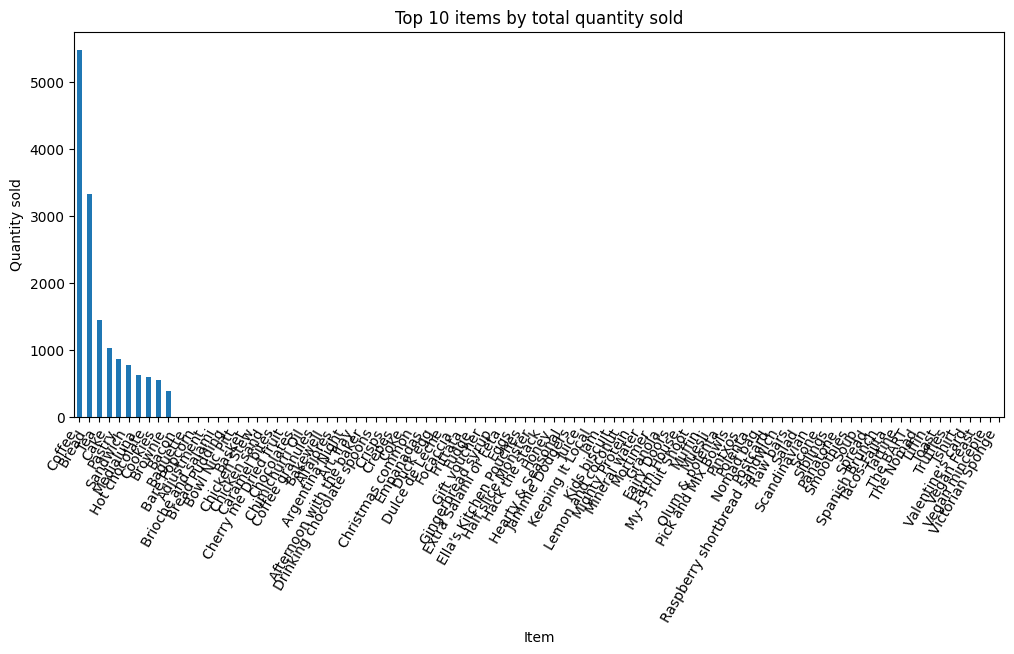

In [36]:
# Plot the top 10 items by total quantity
top_items = item_summary.head(10).index

plot_df = qty_df[qty_df["Item"].isin(top_items)]

plt.figure(figsize=(12, 5))
plot_df.groupby("Item", observed=False)["quantity"].sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Top 10 items by total quantity sold")
plt.ylabel("Quantity sold")
plt.xlabel("Item")
plt.xticks(rotation=60, ha="right")
plt.show()

## 7. Fit a first Linear Mixed Effects Model (LMM)

We model `quantity` as a function of:

- `period_day`
- `weekday_weekend`

and allow the baseline level to vary by `Item` using a random intercept.

This means:
- fixed effects capture general timing patterns
- random effects capture item-specific differences

In [52]:
# First baseline mixed model
# Fixed effects:
#   - period_day
#   - weekday_weekend
# Random intercept:
#   - Item
lmm_1 = smf.mixedlm(
    "quantity ~ period_day + weekday_weekend",
    data=qty_df,
    groups=qty_df["Item"]
)

# Fit the model
# lbfgs is often a good first optimisation method to try
lmm_1_result = lmm_1.fit(method="lbfgs")

# Print the model summary
print(lmm_1_result.summary())

                       Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           quantity
No. Observations:           5627              Method:                       REML    
No. Groups:                 94                Scale:                        7.3630  
Min. group size:            1                 Log-Likelihood:               inf     
Max. group size:            363               Converged:                    Yes     
Mean group size:            59.9                                                    
------------------------------------------------------------------------------------
                           Coef.    Std.Err.     z    P>|z|    [0.025       0.975]  
------------------------------------------------------------------------------------
Intercept                  -0.000 2847723.526  -0.000 1.000 -5581435.548 5581435.548
period_day[T.evening]      -4.015       0.156 -25.778 0.000       -4.320      -3.710
peri

/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values

## 8. Optional second model with month effect

This tests whether adding a seasonal/monthly effect improves the model.
Keep this as an optional extension if the first model is stable.

In [38]:
# Optional richer model with month included as an extra fixed effect
lmm_2 = smf.mixedlm(
    "quantity ~ period_day + weekday_weekend + month",
    data=qty_df,
    groups=qty_df["Item"]
)

# Fit the second model
lmm_2_result = lmm_2.fit(method="lbfgs")

# Show the summary
print(lmm_2_result.summary())

                       Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           quantity
No. Observations:           5627              Method:                       REML    
No. Groups:                 94                Scale:                        7.2489  
Min. group size:            1                 Log-Likelihood:               inf     
Max. group size:            363               Converged:                    Yes     
Mean group size:            59.9                                                    
------------------------------------------------------------------------------------
                           Coef.    Std.Err.     z    P>|z|    [0.025       0.975]  
------------------------------------------------------------------------------------
Intercept                   0.000 2825587.380   0.000 1.000 -5538049.499 5538049.499
period_day[T.evening]      -4.089       0.155 -26.343 0.000       -4.393      -3.784
peri

/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/xi/miniconda3/envs/pred/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values

## 9. Generate quantity predictions and evaluate model fit

We use the first model as the baseline prediction model.
Negative predicted quantities are clipped to zero because quantity cannot be negative.

In [39]:
# Generate predictions from the first mixed model
qty_df["pred_quantity"] = lmm_1_result.predict(qty_df)

# Quantity cannot be negative in practice, so clip negative predictions to zero
qty_df["pred_quantity"] = qty_df["pred_quantity"].clip(lower=0)

# Compute evaluation metrics
# We calculate MSE first, then RMSE manually for compatibility across sklearn versions
mse = mean_squared_error(qty_df["quantity"], qty_df["pred_quantity"])
rmse = np.sqrt(mse)
r2 = r2_score(qty_df["quantity"], qty_df["pred_quantity"])

# Print metrics in a readable format
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

MSE:  32.3271
RMSE: 5.6857
R2:   -0.5256


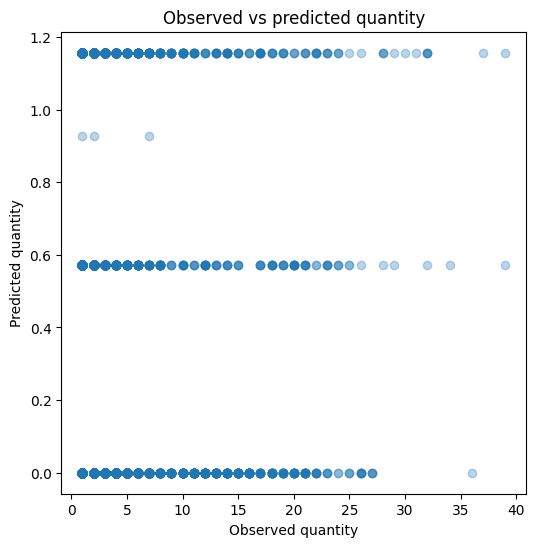

In [40]:
# Plot observed quantity versus predicted quantity
plt.figure(figsize=(6, 6))
plt.scatter(qty_df["quantity"], qty_df["pred_quantity"], alpha=0.3)
plt.xlabel("Observed quantity")
plt.ylabel("Predicted quantity")
plt.title("Observed vs predicted quantity")
plt.show()

## 10. Owner-adjustable price scenarios

Now we separate pricing from demand.

The mixed model predicts quantity.
Revenue is then calculated by multiplying predicted quantity by prices.

This is useful because bakery owners can adjust prices without retraining the quantity model.

In [41]:
# Define owner price adjustments as multipliers on the base price
# 1.10 means +10%
# 0.95 means -5%
owner_price_adjustment = {
    "Coffee": 1.10,
    "Bread": 1.00,
    "Tea": 0.95,
    "Cake": 1.15,
    "Pastry": 1.05
}

# Apply adjusted prices
# If an item is not listed in owner_price_adjustment, keep its multiplier at 1.0
qty_df["adjusted_price"] = qty_df.apply(
    lambda row: row["base_price"] * owner_price_adjustment.get(row["Item"], 1.0),
    axis=1
)

# Preview base and adjusted prices
qty_df[["Item", "base_price", "adjusted_price"]].drop_duplicates().sort_values("Item").head(20)

,Item,base_price,adjusted_price
409,Adjustment,3.5,3.50
2163,Afternoon with the baker,3.5,3.50
76,Alfajores,2.6,2.60
4472,Argentina Night,3.5,3.50
370,Art Tray,3.5,3.50
571,Bacon,3.5,3.50
2785,Baguette,3.5,3.50
1017,Bakewell,3.5,3.50
1594,Bare Popcorn,3.5,3.50
0,Basket,3.5,3.50


In [42]:
# Define owner price adjustments as multipliers on the base price
# 1.10 means +10%
# 0.95 means -5%
owner_price_adjustment = {
    "Coffee": 1.10,
    "Bread": 1.00,
    "Tea": 0.95,
    "Cake": 1.15,
    "Pastry": 1.05
}

# Apply adjusted prices
# If an item is not listed in owner_price_adjustment, keep its multiplier at 1.0
qty_df["adjusted_price"] = qty_df.apply(
    lambda row: row["base_price"] * owner_price_adjustment.get(row["Item"], 1.0),
    axis=1
)

# Preview base and adjusted prices
qty_df[["Item", "base_price", "adjusted_price"]].drop_duplicates().sort_values("Item").head(20)

,Item,base_price,adjusted_price
409,Adjustment,3.5,3.50
2163,Afternoon with the baker,3.5,3.50
76,Alfajores,2.6,2.60
4472,Argentina Night,3.5,3.50
370,Art Tray,3.5,3.50
571,Bacon,3.5,3.50
2785,Baguette,3.5,3.50
1017,Bakewell,3.5,3.50
1594,Bare Popcorn,3.5,3.50
0,Basket,3.5,3.50


In [45]:
# Convert predicted quantity into predicted revenue under two scenarios:
# 1. baseline prices
# 2. owner-adjusted prices
qty_df["pred_revenue_base"] = qty_df["pred_quantity"] * qty_df["base_price"]
qty_df["pred_revenue_adjusted"] = qty_df["pred_quantity"] * qty_df["adjusted_price"]

qty_df.head()

,date,Item,period_day,weekday_weekend,quantity,base_price,baseline_revenue,month,pred_quantity,adjusted_price,pred_revenue_base,pred_revenue_adjusted
0,2016-10-30,Basket,morning,weekend,2,3.5,7.0,10,0.572727,3.50,2.004545,2.004545
1,2016-10-30,Bread,afternoon,weekend,9,3.5,31.5,10,1.156636,3.50,4.048226,4.048226
2,2016-10-30,Bread,morning,weekend,20,3.5,70.0,10,0.572727,3.50,2.004545,2.004545
3,2016-10-30,Cake,afternoon,weekend,1,4.8,4.8,10,1.156636,5.52,5.551852,6.384630
4,2016-10-30,Chicken sand,afternoon,weekend,1,3.5,3.5,10,1.156636,3.50,4.048226,4.048226


## 11. Compare revenue by item

We now compare baseline and adjusted predicted revenue at item level.

In [46]:
# Aggregate predicted revenue by item
revenue_compare = (
    qty_df.groupby("Item", observed=False)[["pred_revenue_base", "pred_revenue_adjusted"]]
    .sum()
    .sort_values("pred_revenue_base", ascending=False)
)

# Show the top items by baseline predicted revenue
revenue_compare.head(15)

,pred_revenue_base,pred_revenue_adjusted
Item,,
Cake,329.395973,378.805368
Sandwich,327.094391,327.094391
Bread,274.379238,274.379238
Hot chocolate,224.360229,224.360229
Coffee,217.899754,239.689729
Farm House,217.748803,217.748803
Pastry,214.430833,225.152375
Tea,188.826080,179.384776
Juice,159.146134,159.146134


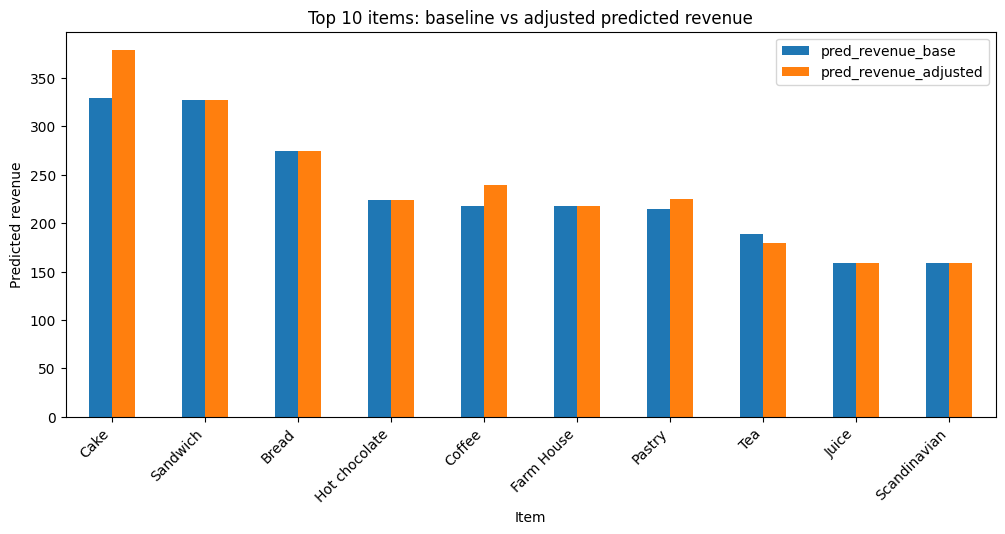

In [47]:
# Plot top 10 items by baseline predicted revenue
top_rev_items = revenue_compare.head(10)

top_rev_items.plot(kind="bar", figsize=(12, 5))
plt.title("Top 10 items: baseline vs adjusted predicted revenue")
plt.ylabel("Predicted revenue")
plt.xlabel("Item")
plt.xticks(rotation=45, ha="right")
plt.show()

## 12. Daily forecast table

A daily revenue forecast is easier to present to stakeholders than raw item-level rows.

In [48]:
# Aggregate daily predicted revenue
daily_forecast = (
    qty_df.groupby("date", observed=False)[["pred_revenue_base", "pred_revenue_adjusted"]]
    .sum()
    .reset_index()
    .sort_values("date")
)

daily_forecast.head()

,date,pred_revenue_base,pred_revenue_adjusted
0,2016-10-30,120.921371,122.131018
1,2016-10-31,0.000000,0.000000
2,2016-11-01,0.000000,0.000000
3,2016-11-02,0.000000,0.000000
4,2016-11-03,0.000000,0.000000


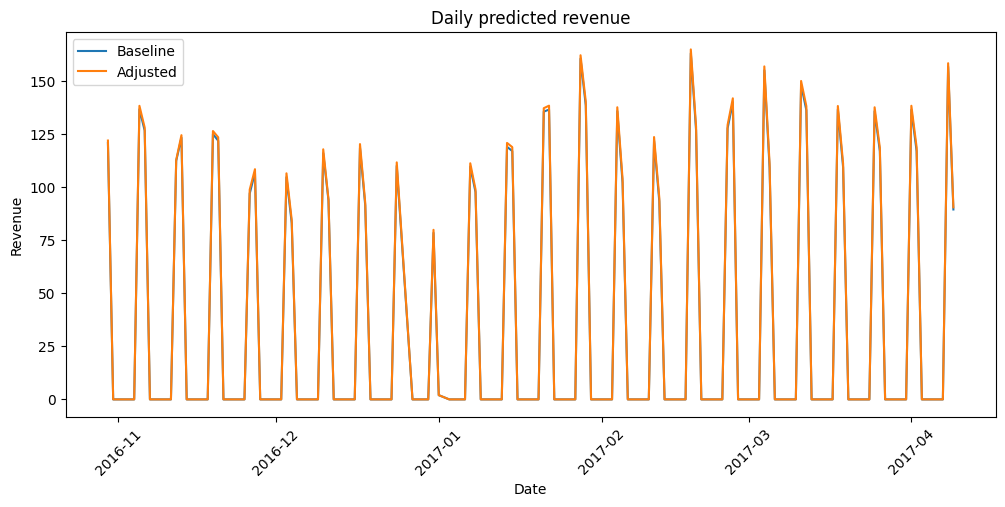

In [49]:
# Plot the daily revenue forecast over time
plt.figure(figsize=(12, 5))
plt.plot(daily_forecast["date"], daily_forecast["pred_revenue_base"], label="Baseline")
plt.plot(daily_forecast["date"], daily_forecast["pred_revenue_adjusted"], label="Adjusted")
plt.title("Daily predicted revenue")
plt.ylabel("Revenue")
plt.xlabel("Date")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## 13. Export outputs

Finally, save the item-level predictions and the daily revenue forecast for later use.

In [ ]:
# Export detailed item-level predictions
qty_df.to_csv("demo/bakery_kaggle/bakery_item_level_predictions.csv", index=False)

# Export daily revenue forecast
daily_forecast.to_csv("demo/bakery_kaggle/bakery_daily_revenue_forecast.csv", index=False)

print("Export complete.")

Export complete.


In [51]:
# Optional helper: check where files are being saved
import os
print("Current working directory:")
print(os.getcwd())

Current working directory:
/mnt/c/Users/xilu/OneDrive/bus/sloxen/products/AutoPred
